In [47]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols

Càrrega de dades

In [ ]:
df = pd.read_csv("dades_calçat.csv")

Definició de la paleta de colors corporativa del projecte

In [ ]:

colors_corredor = {
    'Ligero': '#3498db',   # Blau
    'Medio': '#e67e22',    # Taronja
    'Pesado': '#2ecc71'    # Verd
}

0. CONFIGURACIÓ INICIAL I NETEJA
- FUNCIÓ AUXILIAR CORREGIDA SENSE ERROR D'ATRIBUT 
- SOLUCIÓ REVISADA: auto_set_font_size(False) i iterem per canviar el text de les cel·les

1. GENERACIÓ I EXTRACCIÓ DE LES TAULES ESTADÍSTIQUES
- TAULA A: ANOVA COMBINAT (Pes i Drop)
- Busquem automàticament el nom de la columna del p-value (evita errors si canvia entre versions)
- TAULA B: TEST DE TUKEY (Pes i Drop) 
- TAULA C: DESCRIPTIVA I DISPERSIÓ PER CATEGORIA


In [ ]:

mapeig_catala = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}
df_clean = df.copy()
df_clean['corredor_categoria_cat'] = df_clean['corredor_categoria'].map(mapeig_catala)


def save_table_img(dataframe, title_text, filename, figsize=(8, 3)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.axis('tight')
    
    table = ax.table(
        cellText=dataframe.values, 
        colLabels=dataframe.columns, 
        rowLabels=dataframe.index if dataframe.index.name or not isinstance(dataframe.index, pd.RangeIndex) else None,
        loc='center', 
        cellLoc='center'
    )
    
    table.auto_set_font_size(False)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_fontsize(10) 
        
       
        if row == 0 or col == -1: 
            cell.set_text_props(weight='bold', color='black')
            cell.set_facecolor('#f2f2f2')
        cell.set_linewidth(0.5)
        cell.set_edgecolor('#d3d3d3')

    table.scale(1.2, 1.5)
    plt.title(title_text, fontsize=12, pad=10, weight='normal')
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.close()
    print(f"Imatge desada correctament: {filename}")




mod_pes = ols('Peso_Hombre ~ C(corredor_categoria_cat)', data=df_clean).fit()
anova_pes = sm.stats.anova_lm(mod_pes, typ=2)

mod_drop = ols('Drop ~ C(corredor_categoria_cat)', data=df_clean).fit()
anova_drop = sm.stats.anova_lm(mod_drop, typ=2)

col_p_pes = [c for c in anova_pes.columns if 'PR' in c or 'p' in c][0]
col_p_drop = [c for c in anova_drop.columns if 'PR' in c or 'p' in c][0]

anova_compilado = pd.DataFrame({
    'Variable Analitzada': ['Pes calçat (g)', 'Drop geomètric (mm)'],
    'Estadístic F': [round(anova_pes.loc['C(corredor_categoria_cat)', 'F'], 4), round(anova_drop.loc['C(corredor_categoria_cat)', 'F'], 4)],
    'p-value': [f"{anova_pes.loc['C(corredor_categoria_cat)', col_p_pes]:.2e}", f"{anova_drop.loc['C(corredor_categoria_cat)', col_p_drop]:.2e}"]
})
save_table_img(anova_compilado, "Taula 1: Resultats de l'Anàlisi de Variança (ANOVA d'un factor)", 'taula_1_anova.png', figsize=(7, 2))


df_pes_net = df_clean[['Peso_Hombre', 'corredor_categoria_cat']].dropna()
tukey_p = pairwise_tukeyhsd(endog=df_pes_net['Peso_Hombre'], groups=df_pes_net['corredor_categoria_cat'], alpha=0.05)

df_drop_net = df_clean[['Drop', 'corredor_categoria_cat']].dropna()
tukey_d = pairwise_tukeyhsd(endog=df_drop_net['Drop'], groups=df_drop_net['corredor_categoria_cat'], alpha=0.05)

tukey_resum = pd.DataFrame([
    ['Pes (g)', 'Lleuger vs Mitjà', f"+{abs(tukey_p.meandiffs[1]):.2f}", 'Sí (Rebutjat)'],
    ['Pes (g)', 'Mitjà vs Pesat', f"+{abs(tukey_p.meandiffs[2]):.2f}", 'Sí (Rebutjat)'],
    ['Pes (g)', 'Lleuger vs Pesat', f"+{abs(tukey_p.meandiffs[0]):.2f}", 'Sí (Rebutjat)'],
    ['Drop (mm)', 'Lleuger vs Mitjà', f"+{abs(tukey_d.meandiffs[1]):.2f}", 'Sí (Rebutjat)'],
    ['Drop (mm)', 'Mitjà vs Pesat', f"+{abs(tukey_d.meandiffs[2]):.2f}", 'Sí (Rebutjat)'],
    ['Drop (mm)', 'Lleuger vs Pesat', f"+{abs(tukey_d.meandiffs[0]):.2f}", 'Sí (Rebutjat)']
], columns=['Variable', 'Comparació de Grups', 'Diferència Mitjana', 'Significatiu (p < 0.05)'])

save_table_img(tukey_resum, "Taula 2: Comparacions Múltiples Post-Hoc (Test de Tukey HSD)", 'taula_2_tukey.png', figsize=(8, 3.5))


grouped = df_clean.groupby('corredor_categoria_cat')[['Peso_Hombre', 'Drop']].agg(['mean', 'std'])

grouped[('Peso_Hombre', 'CV (%)')] = (grouped[('Peso_Hombre', 'std')] / grouped[('Peso_Hombre', 'mean')]) * 100
grouped[('Drop', 'CV (%)')] = (grouped[('Drop', 'std')] / grouped[('Drop', 'mean')]) * 100

dispersio_final = pd.DataFrame(index=['Lleuger', 'Mitjà', 'Pesat'])
dispersio_final['Pes Mitjà (g)'] = grouped[('Peso_Hombre', 'mean')].round(2)
dispersio_final['Pes Desv. Est. (g)'] = grouped[('Peso_Hombre', 'std')].round(2)
dispersio_final['Pes CV (%)'] = grouped[('Peso_Hombre', 'CV (%)')].round(2)
dispersio_final['Drop Mitjà (mm)'] = grouped[('Drop', 'mean')].round(2)
dispersio_final['Drop Desv. Est. (mm)'] = grouped[('Drop', 'std')].round(2)
dispersio_final['Drop CV (%)'] = grouped[('Drop', 'CV (%)')].round(2)
dispersio_final.index.name = 'Perfil Corredor'

save_table_img(dispersio_final, "Taula 3: Estadística Descriptiva i Dispersió per Segment de Mercat", 'taula_3_dispersio.png', figsize=(10, 2.5))

Imatge desada correctament: taula_1_anova.png
Imatge desada correctament: taula_2_tukey.png
Imatge desada correctament: taula_3_dispersio.png


Boxplot Pes calçat

/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/3576033443.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/3576033443.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Lleuger', 'Mitjà', 'Pesat'])


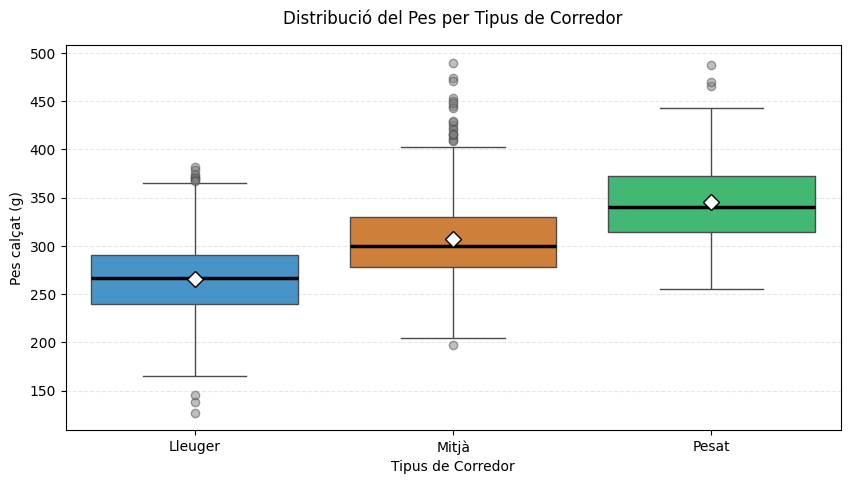

In [ ]:

plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    x='corredor_categoria', 
    y='Peso_Hombre', 
    data=df, 
    palette=colors_corredor,
    order=['Ligero', 'Medio', 'Pesado'],
    showmeans=True,
    meanprops={
        "marker":"D",
        "markerfacecolor":"white",
        "markeredgecolor":"black",
        "markersize": 8
    },
    medianprops={
        "color": "black",     
        "linewidth": 2.5       
    },
    flierprops={
        "marker": "o",             
        "markerfacecolor": "grey",
        "alpha": 0.5
    }
)

ax.set_xticklabels(['Lleuger', 'Mitjà', 'Pesat'])

plt.title('Distribució del Pes per Tipus de Corredor', fontsize=12, pad=15)
plt.ylabel('Pes calçat (g)', fontsize=10) 
plt.xlabel('Tipus de Corredor', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.savefig('boxplot_peso_corredor.png', bbox_inches='tight', dpi=300)
plt.show()

Scatter distribucio pes per tipus corredor

/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/3512694068.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/3512694068.py:33: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


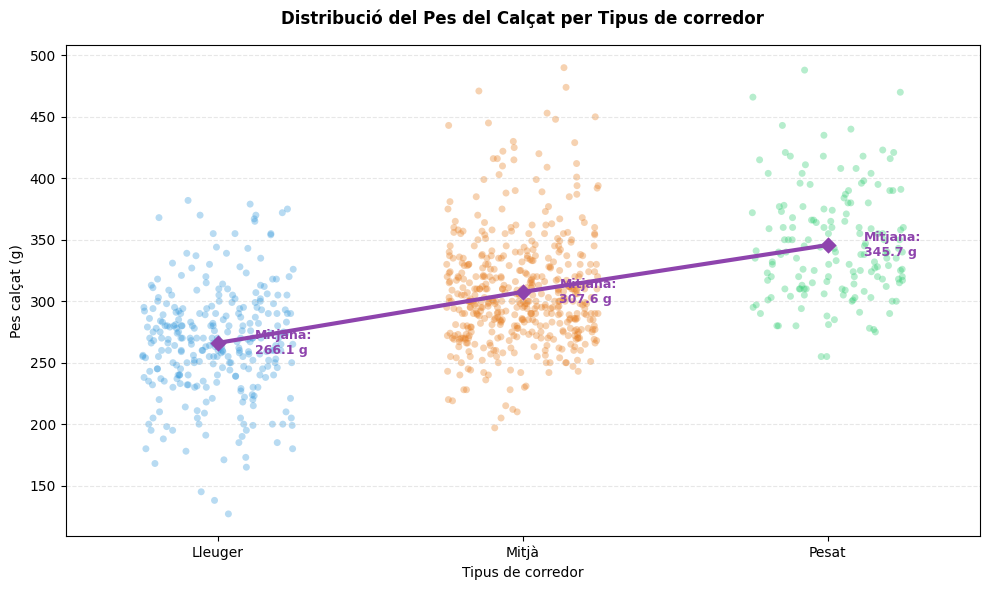

In [ ]:

mapeig_catala = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}
df_scatter = df.dropna(subset=['Peso_Hombre']).copy()
df_scatter['corredor_categoria_cat'] = df_scatter['corredor_categoria'].map(mapeig_catala)

ordre_grups = ['Lleuger', 'Mitjà', 'Pesat']

colors_corredor = {'Lleuger': '#3498db', 'Mitjà': '#e67e22', 'Pesat': '#2ecc71'}

plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df_scatter,
    x='corredor_categoria_cat',
    y='Peso_Hombre',
    order=ordre_grups,
    palette=colors_corredor,
    size=5,
    alpha=0.35,
    jitter=0.25,
    zorder=1
)

mitjanes_pes = df_scatter.groupby('corredor_categoria_cat')['Peso_Hombre'].mean().loc[ordre_grups].reset_index()

color_morat = '#8e44ad'

sns.pointplot(
    data=mitjanes_pes,
    x='corredor_categoria_cat',
    y='Peso_Hombre',
    color=color_morat,
    markers='D',
    scale=1.1,
    linestyles='-',
    zorder=2
)

for i, row in mitjanes_pes.iterrows():
    plt.text(
        i + 0.12, 
        row['Peso_Hombre'], 
        f"Mitjana:\n{row['Peso_Hombre']:.1f} g", 
        color=color_morat, 
        weight='bold', 
        va='center', 
        fontsize=9
    )

plt.title('Distribució del Pes del Calçat per Tipus de corredor', fontsize=12, pad=15, weight='bold')
plt.xlabel('Tipus de corredor', fontsize=10)
plt.ylabel('Pes calçat (g)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('resultats_scatterplot_pes.png', bbox_inches='tight', dpi=300)
plt.show()

3. El Test Estadístic (ANOVA)

In [ ]:
modelo = ols('Peso_Hombre ~ C(corredor_categoria)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

print(tabla_anova)

                             sum_sq     df           F        PR(>F)
C(corredor_categoria)  6.869003e+05    2.0  176.289983  1.468003e-65
Residual               1.796251e+06  922.0         NaN           NaN


Boxplot drop

/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/857937948.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/857937948.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Lleuger', 'Mitjà', 'Pesat'])


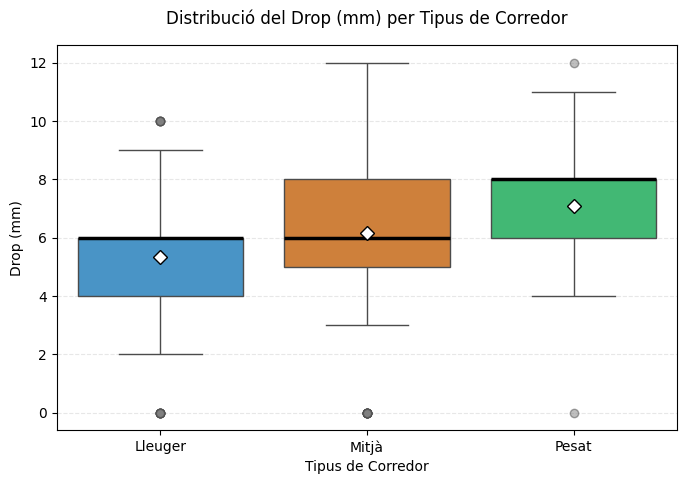

In [ ]:


df_drop_net = df.dropna(subset=['Drop'])

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    x='corredor_categoria', 
    y='Drop', 
    data=df_drop_net, 
    palette=colors_corredor,
    order=['Ligero', 'Medio', 'Pesado'],
    showmeans=True,  
    meanprops={
        "marker":"D",              
        "markerfacecolor":"white", 
        "markeredgecolor":"black", 
        "markersize": 7
    },
    medianprops={
        "color": "black",          
        "linewidth": 2.5           
    },
    flierprops={
        "marker": "o",             
        "markerfacecolor": "grey",
        "alpha": 0.5
    }
)

ax.set_xticklabels(['Lleuger', 'Mitjà', 'Pesat'])

plt.title('Distribució del Drop (mm) per Tipus de Corredor', fontsize=12, pad=15)
plt.xlabel('Tipus de Corredor', fontsize=10)
plt.ylabel('Drop (mm)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3) 

plt.savefig('resultats_2_boxplot_drop.png', bbox_inches='tight', dpi=300)
plt.show()

3. El Test Estadístic (ANOVA)

In [ ]:


modelo = ols('Drop ~ C(corredor_categoria)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

print(tabla_anova)

                            sum_sq     df         F    PR(>F)
C(corredor_categoria)   134.738835    2.0  12.31882  0.000007
Residual               2061.745375  377.0       NaN       NaN


In [5]:
df.groupby('corredor_categoria')[['Peso_Hombre', 'Drop']].mean()

,Peso_Hombre,Drop
corredor_categoria,,
Ligero,266.107639,5.327586
Medio,307.565762,6.147208
Pesado,345.696203,7.089552


Tuckey pes i drop

In [ ]:
df_pes_net = df[['Peso_Hombre', 'corredor_categoria']].dropna()

tukey_pes = pairwise_tukeyhsd(endog=df_pes_net['Peso_Hombre'], 
                              groups=df_pes_net['corredor_categoria'], 
                              alpha=0.05)
print("--- TUKEY PES (CORREGIT) ---")
print(tukey_pes)

tukey_drop = pairwise_tukeyhsd(endog=df['Drop'].dropna(), groups=df[df['Drop'].notna()]['corredor_categoria'], alpha=0.05)
print("--- TUKEY DROP ---")
print(tukey_drop)

--- TUKEY PES (CORREGIT) ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Ligero  Medio  41.4581   0.0 33.7321 49.1842   True
Ligero Pesado  79.5886   0.0 69.3305 89.8466   True
 Medio Pesado  38.1304   0.0 28.6245 47.6364   True
---------------------------------------------------
--- TUKEY DROP ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
Ligero  Medio   0.8196 0.0082 0.1756 1.4636   True
Ligero Pesado    1.762    0.0 0.9176 2.6063   True
 Medio Pesado   0.9423 0.0128 0.1641 1.7206   True
--------------------------------------------------


Scatter pes i drop

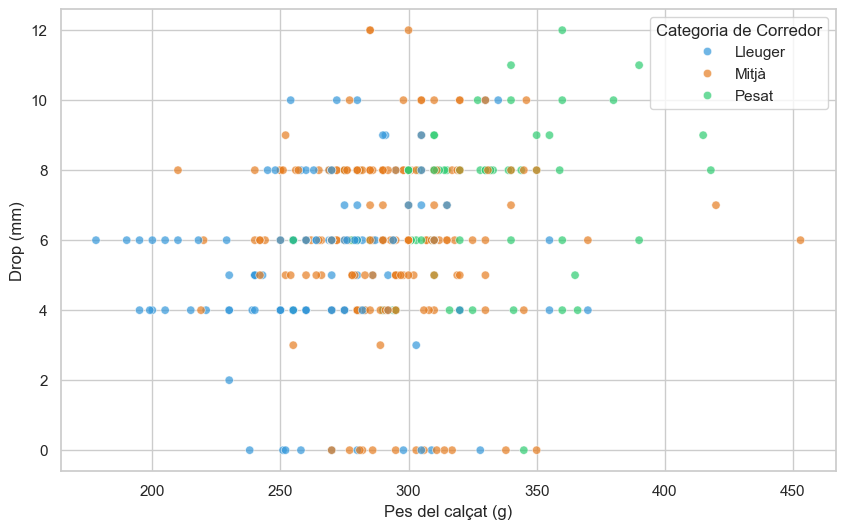

In [ ]:

df_scatter = df.copy()

traduccio_categories = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}
df_scatter['corredor_categoria_cat'] = df_scatter['corredor_categoria'].map(traduccio_categories)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_scatter, 
    x='Peso_Hombre', 
    y='Drop', 
    hue='corredor_categoria_cat', 
    alpha=0.7, 
    palette=colors_corredor_cat
)

plt.xlabel('Pes del calçat (g)') 
plt.ylabel('Drop (mm)')

plt.legend(title='Categoria de Corredor')

plt.savefig('scatter_context_net.png', bbox_inches='tight', dpi=300)
plt.show()

- GRÀFIC DE MARQUES REVISAT (Top 15 per volum de models)
- EVOLUCIÓ TEMPORAL

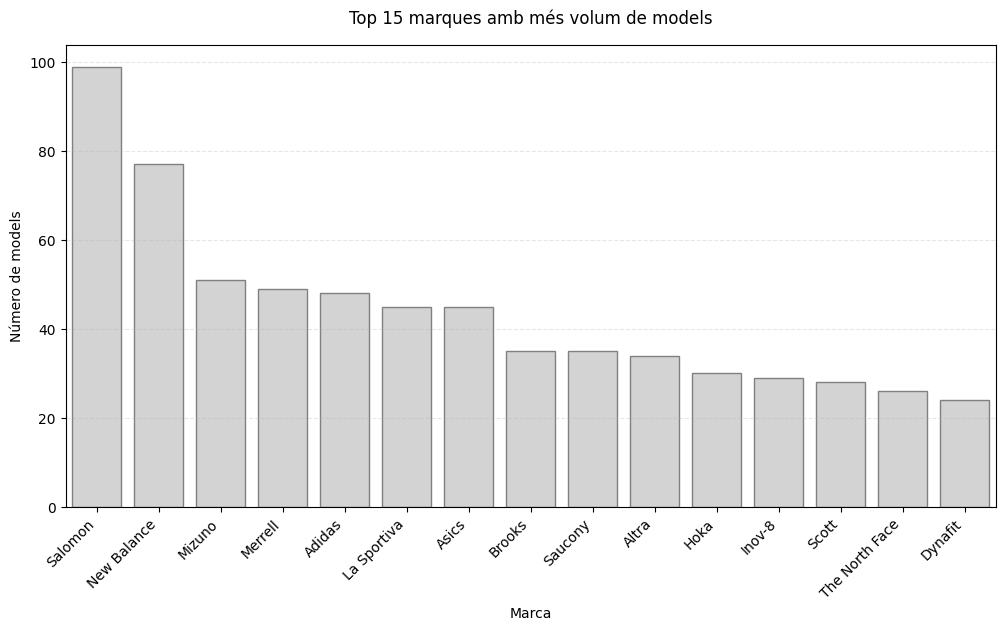

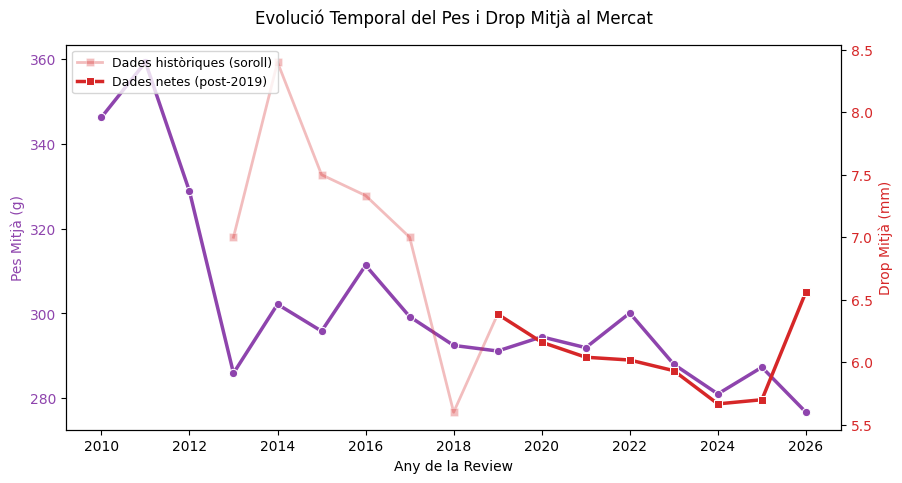

In [ ]:

top_15_marques = df['Marca'].value_counts().head(15).index
df_top15 = df[df['Marca'].isin(top_15_marques)]

plt.figure(figsize=(12, 6))

sns.countplot(data=df_top15, x='Marca', order=top_15_marques, color='lightgrey', edgecolor='grey')

plt.title('Top 15 marques amb més volum de models', fontsize=12, pad=15)
plt.xlabel('Marca', fontsize=10)
plt.ylabel('Número de models', fontsize=10) 
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.savefig('2_marques_volum.png', bbox_inches='tight', dpi=300)
plt.show()



if 'year' in df.columns:
    df_temporal = df.groupby('year')[['Peso_Hombre', 'Drop']].mean().reset_index()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    

    color_pes = '#8e44ad' 
    ax1.set_xlabel('Any de la Review', fontsize=10)
    ax1.set_ylabel('Pes Mitjà (g)', color=color_pes, fontsize=10)
    
    sns.lineplot(data=df_temporal, x='year', y='Peso_Hombre', ax=ax1, color=color_pes, marker='o', linewidth=2.5)
    ax1.tick_params(axis='y', labelcolor=color_pes)
    
   
    ax2 = ax1.twinx()
    color_drop = 'tab:red'
    ax2.set_ylabel('Drop Mitjà (mm)', color=color_drop, fontsize=10)
    
    df_antic = df_temporal[(df_temporal['year'] >= 2012) & (df_temporal['year'] <= 2019)]
    if not df_antic.empty:
        sns.lineplot(data=df_antic, x='year', y='Drop', ax=ax2, color=color_drop, marker='s', 
                     alpha=0.3, linewidth=2, label='Dades històriques (soroll)')
        
    df_recent = df_temporal[df_temporal['year'] >= 2019]
    if not df_recent.empty:
        sns.lineplot(data=df_recent, x='year', y='Drop', ax=ax2, color=color_drop, marker='s', 
                     alpha=1.0, linewidth=2.5, label='Dades netes (post-2019)')
    
    ax2.tick_params(axis='y', labelcolor=color_drop)
    
    ax2.legend(loc='upper left', frameon=True, fontsize=9)
    
    plt.title('Evolució Temporal del Pes i Drop Mitjà al Mercat', fontsize=12, pad=15)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    plt.savefig('3_evolucio_temporal.png', bbox_inches='tight', dpi=300)
    plt.show()

Distribucio de % models per tipus de corredor

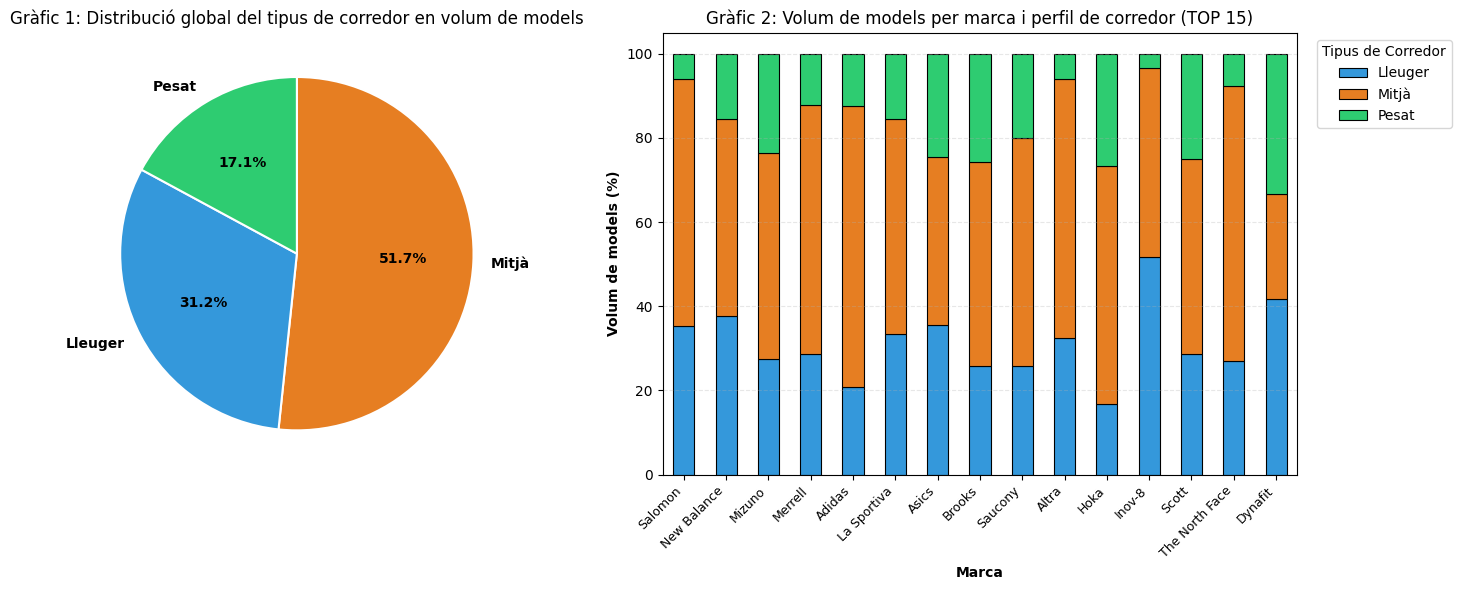

In [ ]:

mapeig_catala = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}

df_grafic = df.copy()
df_grafic['corredor_categoria_cat'] = df_grafic['corredor_categoria'].map(mapeig_catala)

colors_corredor = {'Lleuger': '#3498db', 'Mitjà': '#e67e22', 'Pesat': '#2ecc71'}
top_15_marques = df_grafic['Marca'].value_counts().head(15).index
df_top15 = df_grafic[df_grafic['Marca'].isin(top_15_marques)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

counts = df_grafic['corredor_categoria_cat'].value_counts().sort_values(ascending=False)
colors_ordenats = [colors_corredor[index] for index in counts.index]

counts.plot.pie(
    autopct='%1.1f%%', colors=colors_ordenats, startangle=90, counterclock=False,
    textprops={'fontsize': 10, 'weight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    ax=ax1
)
ax1.set_title('Gràfic 1: Distribució global del tipus de corredor en volum de models', fontsize=12)
ax1.set_ylabel('')

df_pivot = pd.crosstab(df_top15['Marca'], df_top15['corredor_categoria_cat'], normalize='index') * 100
columnes_ordre = [c for c in ['Lleuger', 'Mitjà', 'Pesat'] if c in df_pivot.columns]
df_pivot = df_pivot.loc[top_15_marques, columnes_ordre]

df_pivot.plot(
    kind='bar', stacked=True, color=colors_corredor, edgecolor='black', linewidth=0.8, 
    ax=ax2
)
ax2.set_title('Gràfic 2: Volum de models per marca i perfil de corredor (TOP 15)', fontsize=12)
ax2.set_xlabel('Marca', fontsize=10, weight='bold')
ax2.set_ylabel('Volum de models (%)', fontsize=10, weight='bold') 
ax2.legend(title='Tipus de Corredor', loc='upper left', bbox_to_anchor=(1.02, 1))
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('figura_1_context.png', bbox_inches='tight', dpi=300)
plt.show()

SCATTER PLOT DIVIDIT EN 3 (FACETS) PER ANALITZAR LA DISPERSIÓ

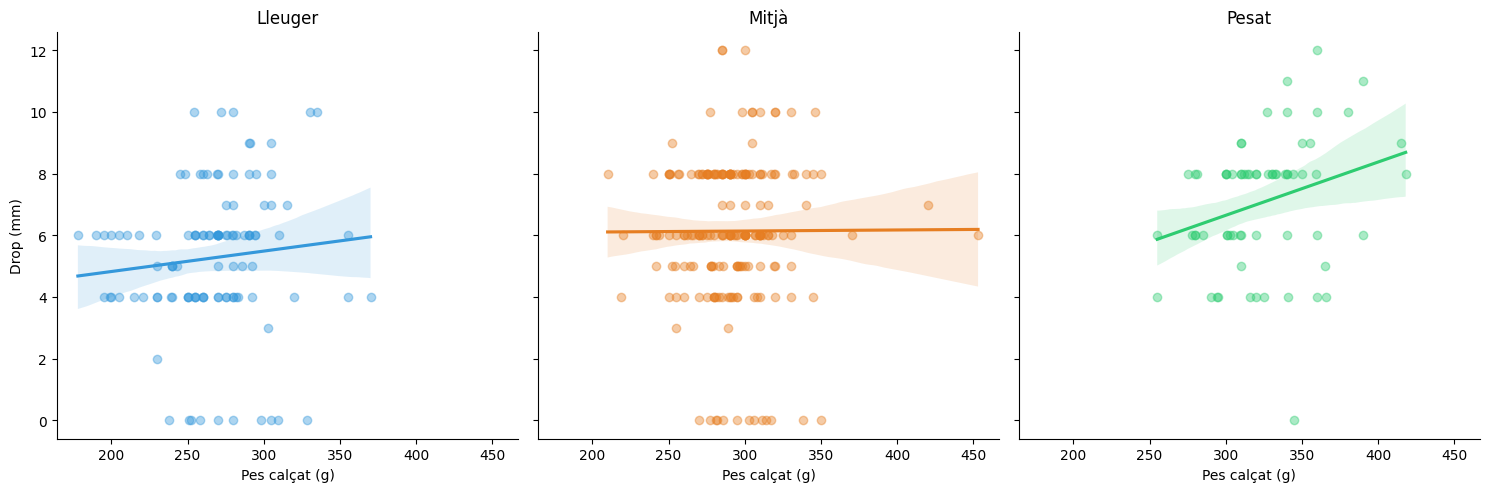

In [ ]:

df_scatter_net = df_grafic.dropna(subset=['Drop', 'Peso_Hombre'])

g = sns.lmplot(
    data=df_scatter_net, 
    x='Peso_Hombre', 
    y='Drop', 
    col='corredor_categoria_cat', 
    hue='corredor_categoria_cat', 
    palette=colors_corredor, 
    col_order=['Lleuger', 'Mitjà', 'Pesat'], 
    height=5, 
    aspect=1, 
    scatter_kws={'alpha':0.4}
)

g.set_axis_labels("Pes calçat (g)", "Drop (mm)")

for ax, title in zip(g.axes.flat, ['Lleuger', 'Mitjà', 'Pesat']):
    ax.set_title(title, fontsize=12, weight='normal') # weight='normal' treu la negreta

plt.savefig('context_3_scatter_dividit.png', bbox_inches='tight', dpi=300)
plt.show()

GRÀFIC COMBINAT: VOLUM DE MODELS vs PES MITJÀ

/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/3085799715.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_15_marques, rotation=45, ha='right')


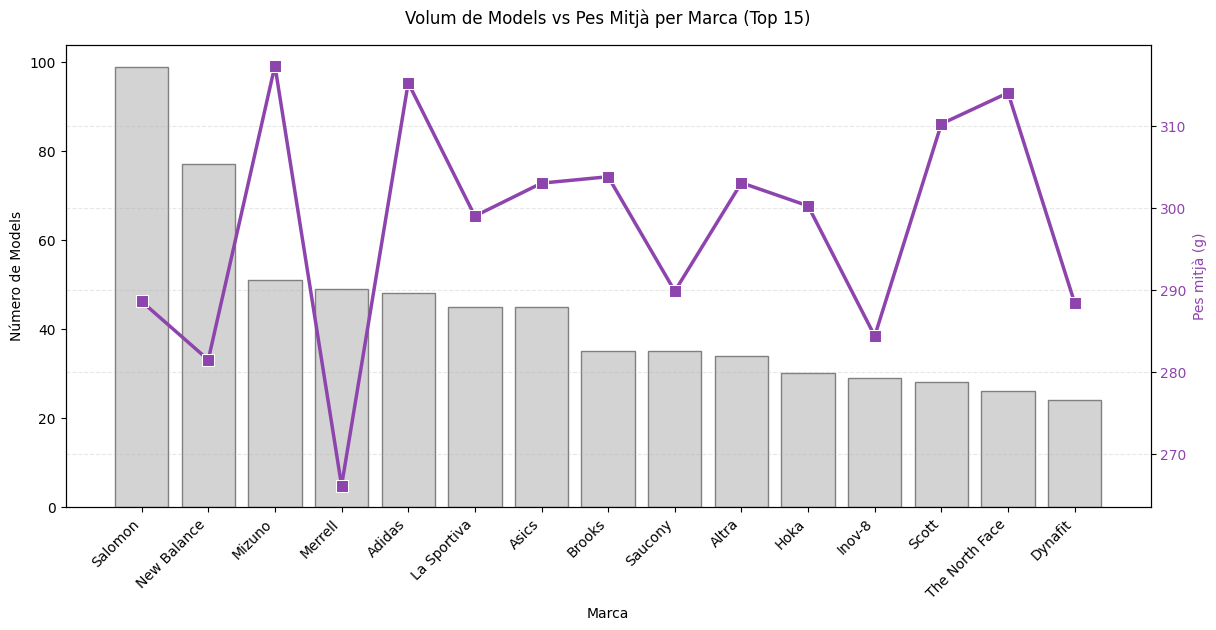

In [ ]:

top_15_marques = df['Marca'].value_counts().head(15).index
df_top15 = df[df['Marca'].isin(top_15_marques)]

fig, ax1 = plt.subplots(figsize=(14, 6))

color_barres = 'lightgrey'
sns.countplot(data=df_top15, x='Marca', order=top_15_marques, ax=ax1, color=color_barres, edgecolor='grey')

plt.title('Volum de Models vs Pes Mitjà per Marca (Top 15)', fontsize=12, pad=15)
ax1.set_xlabel('Marca', fontsize=10)

ax1.set_ylabel('Número de Models', color='black', fontsize=10)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticklabels(top_15_marques, rotation=45, ha='right')

ax2 = ax1.twinx()
df_pes_mitja = df_top15.groupby('Marca')['Peso_Hombre'].mean().loc[top_15_marques].reset_index()

color_linia = '#8e44ad' 
sns.lineplot(
    data=df_pes_mitja, 
    x='Marca', 
    y='Peso_Hombre', 
    ax=ax2, 
    color=color_linia, 
    marker='s', 
    markersize=8,
    sort=False, 
    linewidth=2.5
)

ax2.set_ylabel('Pes mitjà (g)', color=color_linia, fontsize=10)
ax2.tick_params(axis='y', labelcolor=color_linia)
ax2.grid(axis='y', linestyle='--', alpha=0.3) 

plt.savefig('context_5_marques_pes.png', bbox_inches='tight', dpi=300)
plt.show()

GRÀFIC COMBINAT: VOLUM DE MODELS vs DROP MITJÀ

/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/1757314419.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_15_marques, rotation=45, ha='right')


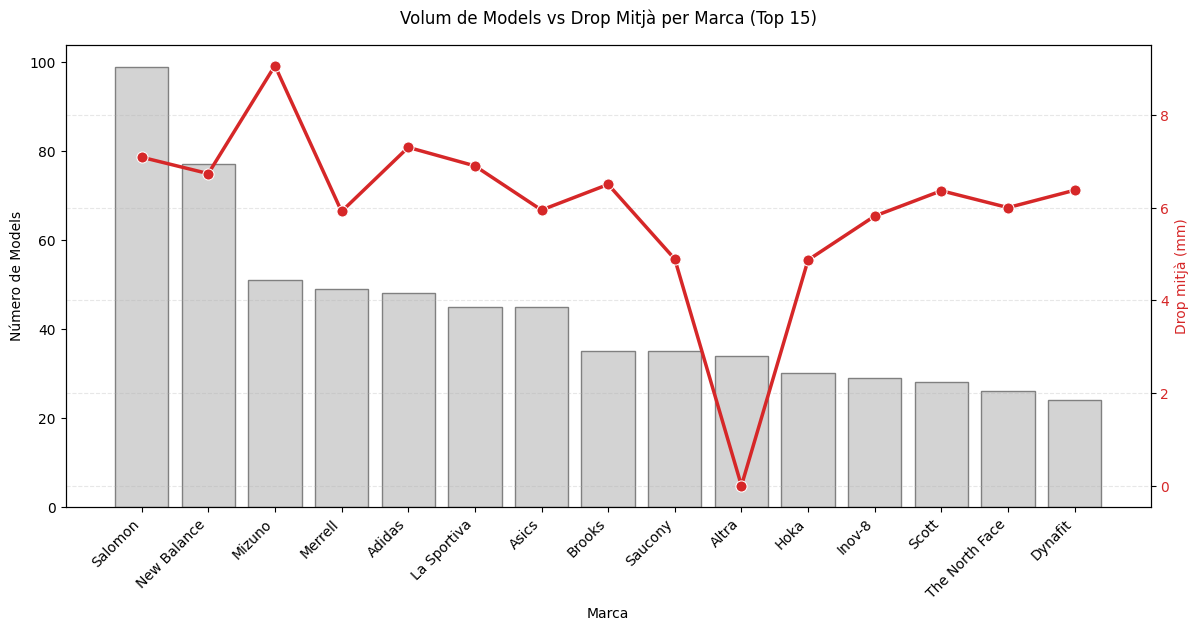

In [ ]:

top_15_marques = df['Marca'].value_counts().head(15).index
df_top15 = df[df['Marca'].isin(top_15_marques)]

fig, ax1 = plt.subplots(figsize=(14, 6))

color_barres = 'lightgrey'
sns.countplot(data=df_top15, x='Marca', order=top_15_marques, ax=ax1, color=color_barres, edgecolor='grey')

plt.title('Volum de Models vs Drop Mitjà per Marca (Top 15)', fontsize=12, pad=15)
ax1.set_xlabel('Marca', fontsize=10)

ax1.set_ylabel('Número de Models', color='black', fontsize=10)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticklabels(top_15_marques, rotation=45, ha='right')

ax2 = ax1.twinx()
df_drop_mitja = df_top15.groupby('Marca')['Drop'].mean().loc[top_15_marques].reset_index()

color_linia = 'tab:red'
sns.lineplot(
    data=df_drop_mitja, 
    x='Marca', 
    y='Drop', 
    ax=ax2, 
    color=color_linia, 
    marker='o',
    markersize=8,
    sort=False, 
    linewidth=2.5
)

ax2.set_ylabel('Drop mitjà (mm)', color=color_linia, fontsize=10)
ax2.tick_params(axis='y', labelcolor=color_linia)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.savefig('context_4_marques_combinat_revisat.png', bbox_inches='tight', dpi=300)
plt.show()

- DISPERSIÓ GLOBAL
- DISPERSIÓ PER TIPUS DE CORREDOR (El moll de l'os)

In [ ]:

print("--- DISPERSIÓ GLOBAL ---")
dispersio_global = df[['Peso_Hombre', 'Drop']].agg(['mean', 'std', 'min', 'max'])
dispersio_global.loc['CV (%)'] = (dispersio_global.loc['std'] / dispersio_global.loc['mean']) * 100
print(dispersio_global.round(2))
print("\n" + "="*40 + "\n")

print("--- DISPERSIÓ PER TIPUS DE CORREDOR ---")
grouped = df.groupby('corredor_categoria')[['Peso_Hombre', 'Drop']].agg(['mean', 'std'])

grouped[('Peso_Hombre', 'CV (%)')] = (grouped[('Peso_Hombre', 'std')] / grouped[('Peso_Hombre', 'mean')]) * 100
grouped[('Drop', 'CV (%)')] = (grouped[('Drop', 'std')] / grouped[('Drop', 'mean')]) * 100

grouped = grouped.reindex(columns=[
    ('Peso_Hombre', 'mean'), ('Peso_Hombre', 'std'), ('Peso_Hombre', 'CV (%)'),
    ('Drop', 'mean'), ('Drop', 'std'), ('Drop', 'CV (%)')
])

print(grouped.round(2))


--- DISPERSIÓ GLOBAL ---
        Peso_Hombre   Drop
mean         301.17   6.06
std           51.84   2.41
min          127.00   0.00
max          490.00  12.00
CV (%)        17.21  39.71


--- DISPERSIÓ PER TIPUS DE CORREDOR ---
                   Peso_Hombre                Drop             
                          mean    std CV (%)  mean   std CV (%)
corredor_categoria                                             
Ligero                  266.11  43.98  16.53  5.33  2.37  44.47
Medio                   307.57  44.27  14.39  6.15  2.38  38.80
Pesado                  345.70  44.03  12.74  7.09  2.14  30.15


Outliers DROP

In [ ]:
print(df[df['Drop'] == 0]['Marca'].value_counts())

Marca
Altra            17
Topo Athletic     3
Inov-8            2
Merrell           2
Name: count, dtype: int64


grafic distribucio drops marques barefoot i resta

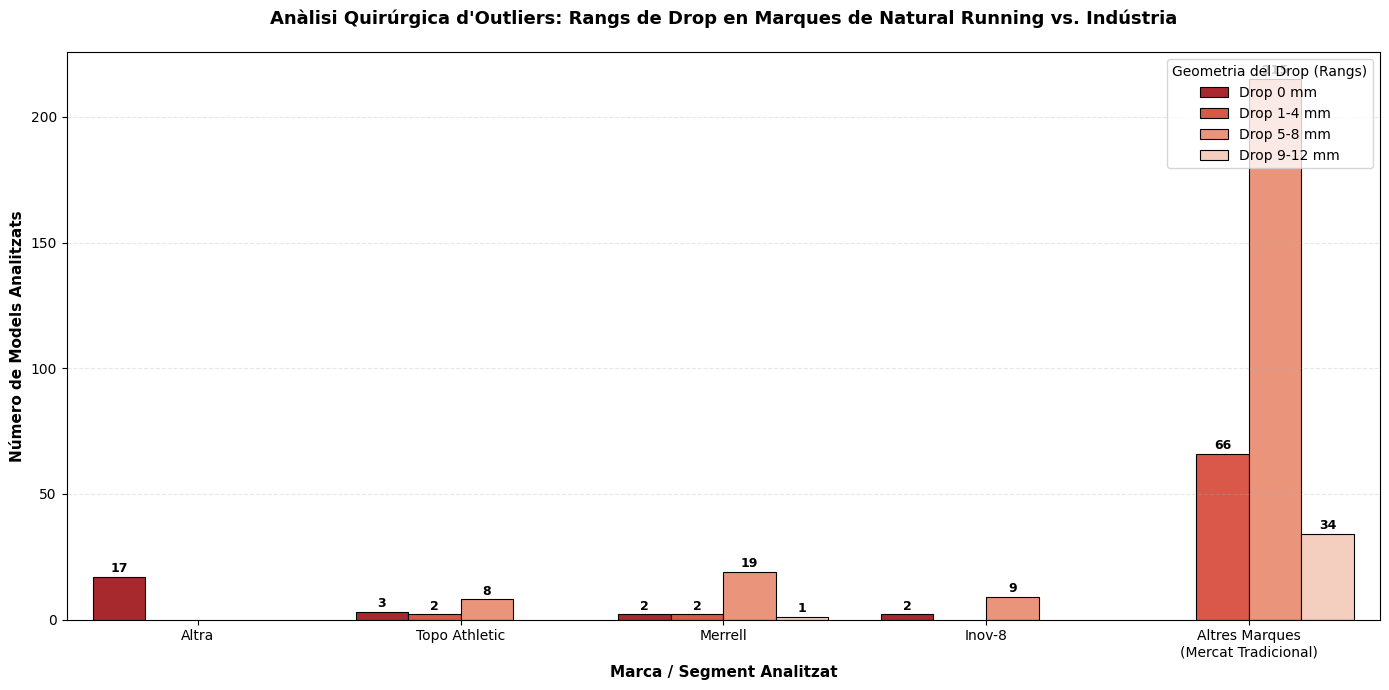

In [ ]:

df_marques = df.dropna(subset=['Drop']).copy()

marques_objectiu = ['Altra', 'Topo Athletic', 'Merrell', 'Inov-8']

def agrupar_marques(marca):
    if marca in marques_objectiu:
        return marca
    else:
        return 'Altres Marques\n(Mercat Tradicional)'

df_marques['Marca_Analisi'] = df_marques['Marca'].apply(agrupar_marques)

bins = [-1, 0, 4, 8, 12]
labels = ['Drop 0 mm', 'Drop 1-4 mm', 'Drop 5-8 mm', 'Drop 9-12 mm']
df_marques['Rang_Drop'] = pd.cut(df_marques['Drop'], bins=bins, labels=labels)

ordre_x = ['Altra', 'Topo Athletic', 'Merrell', 'Inov-8', 'Altres Marques\n(Mercat Tradicional)']

plt.figure(figsize=(14, 7))
ax = sns.countplot(
    data=df_marques,
    x='Marca_Analisi',
    order=ordre_x,
    hue='Rang_Drop',
    palette='Reds_r',
    edgecolor='black',
    linewidth=0.8
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 6),
                    textcoords='offset points',
                    fontsize=9, weight='bold')

plt.title("Anàlisi Quirúrgica d'Outliers: Rangs de Drop en Marques de Natural Running vs. Indústria", fontsize=13, pad=20, weight='bold')
plt.xlabel("Marca / Segment Analitzat", fontsize=11, weight='bold')
plt.ylabel("Número de Models Analitzats", fontsize=11, weight='bold')
plt.legend(title="Geometria del Drop (Rangs)", loc='upper right', fontsize=10)
plt.xticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('outliers_drop_desglosat_marques.png', bbox_inches='tight', dpi=300)
plt.show()

Grafic distribucio drop 0 per marca i tipus de corredor

/var/folders/9_/3pn1l9cn1674q1mxwt092dy00000gn/T/ipykernel_2036/1708187601.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


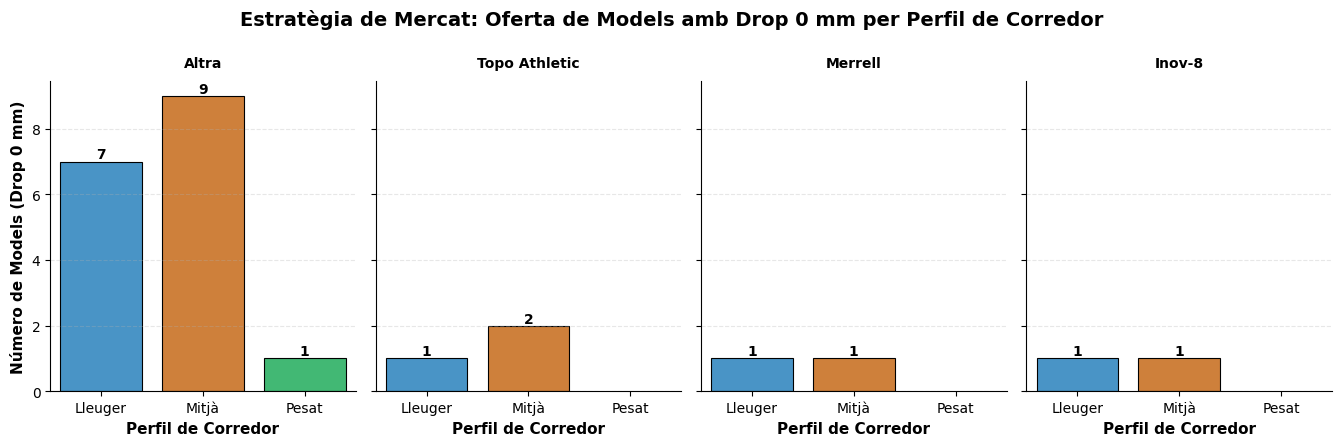

In [ ]:

mapeig_catala = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}
df_analisis = df.copy()
df_analisis['corredor_categoria_cat'] = df_analisis['corredor_categoria'].map(mapeig_catala)

marques_drop_zero = ['Altra', 'Topo Athletic', 'Merrell', 'Inov-8']
df_zero_exclusive = df_analisis[(df_analisis['Drop'] == 0) & (df_analisis['Marca'].isin(marques_drop_zero))]

colors_corredor = {'Lleuger': '#3498db', 'Mitjà': '#e67e22', 'Pesat': '#2ecc71'}

g = sns.catplot(
    data=df_zero_exclusive,
    x='corredor_categoria_cat',
    col='Marca',
    kind='count',
    col_order=marques_drop_zero,
    order=['Lleuger', 'Mitjà', 'Pesat'],
    palette=colors_corredor,
    edgecolor='black',
    linewidth=0.8,
    height=4.5,
    aspect=0.75
)

for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=10, weight='bold')
    
    ax.grid(axis='y', linestyle='--', alpha=0.3)

g.set_axis_labels("Perfil de Corredor", "Número de Models (Drop 0 mm)", fontsize=11, weight='bold')
g.set_titles("{col_name}", fontsize=12, weight='bold', pad=10) # Noms de les marques nets com a títol de columna

plt.subplots_adjust(top=0.82)
g.fig.suptitle("Estratègia de Mercat: Oferta de Models amb Drop 0 mm per Perfil de Corredor", fontsize=14, weight='bold', y=0.98)

plt.savefig('outliers_drop_zero_per_corredor_marca.png', bbox_inches='tight', dpi=300)
plt.show()

Revisem que aquest model d'Altra amb drop = 0 sigui l'únic que hi ha al dataset per corredors pesats

In [ ]:
df_pesats_zero = df[(df['corredor_categoria'] == 'Pesado') & (df['Drop'] == 0)]

print(f"=== RECOMPTE TOTAL: {len(df_pesats_zero)} models ===")
print("-" * 40)
print(df_pesats_zero['Marca'].value_counts())
print("-" * 40)

=== RECOMPTE TOTAL: 1 models ===
----------------------------------------
Marca
Altra    1
Name: count, dtype: int64
----------------------------------------


Tuckey sense outliers del drop 0

In [ ]:

mapeig_catala = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}
df_exp = df.dropna(subset=['Drop']).copy()
df_exp['corredor_categoria_cat'] = df_exp['corredor_categoria'].map(mapeig_catala)

df_filtrat = df_exp[~df_exp['Marca'].isin(['Altra', 'Topo Athletic'])]


model_drop_filtrat = ols('Drop ~ C(corredor_categoria_cat)', data=df_filtrat).fit()
anova_drop_filtrat = sm.stats.anova_lm(model_drop_filtrat, typ=2)

tukey_d_filtrat = pairwise_tukeyhsd(
    endog=df_filtrat['Drop'], 
    groups=df_filtrat['corredor_categoria_cat'], 
    alpha=0.05
)

print("=== EXPERIMENT: ANOVA DEL DROP SENSE NATURAL RUNNING ===")
print(anova_drop_filtrat)
print("\n" + "="*60 + "\n")
print("=== EXPERIMENT: TUKEY HSD SENSE NATURAL RUNNING ===")
print(tukey_d_filtrat)
print("\n" + "="*60 + "\n")
print("=== NOVES MITJANES NETES DE DROP PER GRUP ===")
print(df_filtrat.groupby('corredor_categoria_cat')['Drop'].mean().round(2))



=== EXPERIMENT: ANOVA DEL DROP SENSE NATURAL RUNNING ===
                                sum_sq     df          F    PR(>F)
C(corredor_categoria_cat)    93.528202    2.0  12.607072  0.000005
Residual                   1287.146084  347.0        NaN       NaN


=== EXPERIMENT: TUKEY HSD SENSE NATURAL RUNNING ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Lleuger  Mitjà   0.8512  0.001  0.2961 1.4063   True
Lleuger  Pesat   1.4493    0.0  0.7398 2.1589   True
  Mitjà  Pesat   0.5981 0.0809 -0.0557 1.2519  False
----------------------------------------------------


=== NOVES MITJANES NETES DE DROP PER GRUP ===
corredor_categoria_cat
Lleuger    5.75
Mitjà      6.60
Pesat      7.20
Name: Drop, dtype: float64


DESCRIPTIVA I DISPERSIÓ MODIFICADA sense drop 0

In [ ]:

grouped_exp = df_filtrat.groupby('corredor_categoria_cat')['Drop'].agg(['mean', 'std', 'count'])
grouped_exp['CV (%)'] = (grouped_exp['std'] / grouped_exp['mean']) * 100

dispersio_experiment_df = pd.DataFrame(index=['Lleuger', 'Mitjà', 'Pesat'])
dispersio_experiment_df['Models Analitzats (N)'] = grouped_exp['count'].astype(int)
dispersio_experiment_df['Drop Mitjà (mm)'] = grouped_exp['mean'].round(2)
dispersio_experiment_df['Desviació Estàndard (mm)'] = grouped_exp['std'].round(2)
dispersio_experiment_df['Coeficient de Variació - CV (%)'] = grouped_exp['CV (%)'].round(2)
dispersio_experiment_df.index.name = 'Perfil Corredor'

print("\n" + "="*70)
print("=== 3. EXPERIMENT: DESCRIPTIVA I DISPERSIÓ DEL DROP REVISADA ===")
print("="*70)
print(dispersio_experiment_df)
print("="*70 + "\n")

renderizar_y_guardar_tabla(
    dispersio_experiment_df, 
    "Taula Experiment 3: Mètrics de Dispersió del Drop en el Mercat Tradicional", 
    'experiment_taula_dispersio_drop.png', 
    figsize=(9.5, 2.5)
)

print("[SISTEMA BIEN] Les tres taules experimentals s'han imprès i guardat correctament a la teva carpeta.")


=== 1. EXPERIMENT: ANOVA DEL DROP (SENSE NATURAL RUNNING) ===
                                sum_sq     df          F    PR(>F)
C(corredor_categoria_cat)    93.528202    2.0  12.607072  0.000005
Residual                   1287.146084  347.0        NaN       NaN

=== 2. EXPERIMENT: TEST DE TUKEY HSD (SENSE NATURAL RUNNING) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
Lleuger  Mitjà   0.8512  0.001  0.2961 1.4063   True
Lleuger  Pesat   1.4493    0.0  0.7398 2.1589   True
  Mitjà  Pesat   0.5981 0.0809 -0.0557 1.2519  False
----------------------------------------------------

=== 3. EXPERIMENT: DESCRIPTIVA I DISPERSIÓ DEL DROP REVISADA ===
                 Models Analitzats (N)  Drop Mitjà (mm)  \
Perfil Corredor                                           
Lleuger                            107             5.75   
Mitjà                              177             6.60 

Temporalitat pes per tipus de corredor

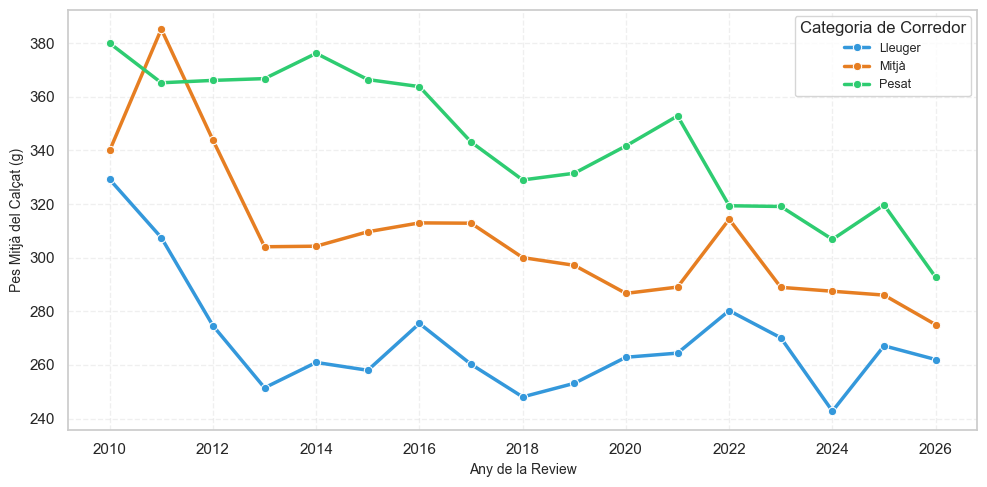

In [ ]:

if 'year' in df.columns:
    
    df_temp_pes = df.groupby(['year', 'corredor_categoria'])['Peso_Hombre'].mean().reset_index()

    traduccio_categories = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}
    df_temp_pes['corredor_categoria_cat'] = df_temp_pes['corredor_categoria'].map(traduccio_categories)

    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.lineplot(
        data=df_temp_pes, 
        x='year', 
        y='Peso_Hombre', 
        hue='corredor_categoria_cat', 
        palette=colors_corredor_cat, 
        marker='o', 
        linewidth=2.5,
        markersize=6,
        ax=ax
    )
    
    ax.set_xlabel('Any de la Review', fontsize=10)
    ax.set_ylabel('Pes Mitjà del Calçat (g)', fontsize=10)
    ax.grid(axis='both', linestyle='--', alpha=0.3)
    ax.legend(title='Categoria de Corredor', loc='upper right', frameon=True, fontsize=9)
    
    plt.tight_layout()
    plt.savefig('3a_evolucio_temporal_peso.png', bbox_inches='tight', dpi=300)
    plt.show()

Temporalitat drop per tipus de corredor

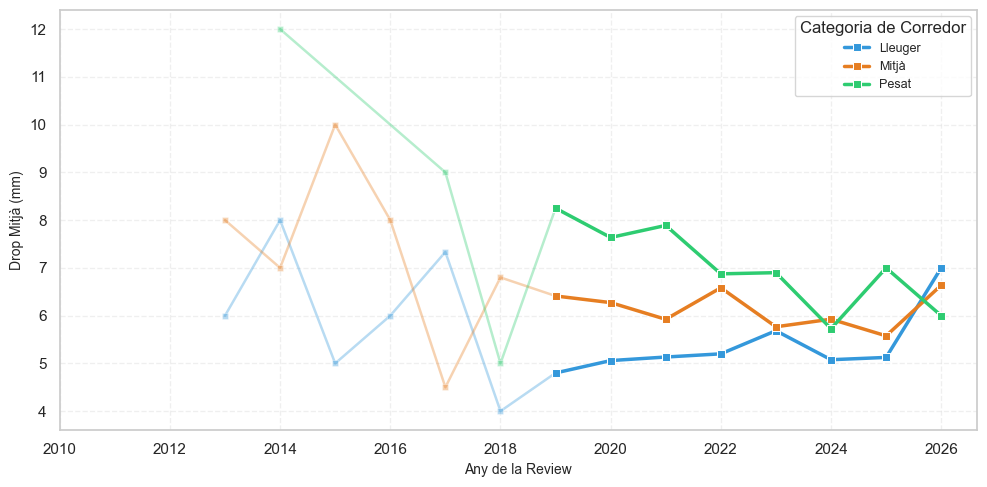

In [ ]:

if 'year' in df.columns:
   
    df_filtrat_drop = df[df['year'] >= 2010]
    df_temp_drop = df_filtrat_drop.groupby(['year', 'corredor_categoria'])['Drop'].mean().reset_index()

    traduccio_categories = {'Ligero': 'Lleuger', 'Medio': 'Mitjà', 'Pesado': 'Pesat'}
    df_temp_drop['corredor_categoria_cat'] = df_temp_drop['corredor_categoria'].map(traduccio_categories)

    fig, ax = plt.subplots(figsize=(10, 5))
    
    categories = ['Lleuger', 'Mitjà', 'Pesat']
    
    for cat in categories:
        df_cat = df_temp_drop[df_temp_drop['corredor_categoria_cat'] == cat]
        color_actual = colors_corredor_cat[cat]
        
        df_antic = df_cat[(df_cat['year'] >= 2010) & (df_cat['year'] <= 2019)]
        if not df_antic.empty:
            sns.lineplot(
                data=df_antic, x='year', y='Drop', ax=ax, 
                color=color_actual, marker='s', alpha=0.35, linewidth=1.8, markersize=5
            )
            ax.text(
                x=df_antic['year'].iloc[-1], y=df_antic['Drop'].iloc[-1],
                s=cat, ha='left', va='center', fontsize=9, color=color_actual
            )
        df_recent = df_cat[df_cat['year'] >= 2019]
        if not df_recent.empty:
            sns.lineplot(
                data=df_recent, x='year', y='Drop', ax=ax, 
                color=color_actual, marker='s', alpha=1.0, linewidth=2.5, markersize=6,
                label=cat 
            )
    
    ax.set_xlabel('Any de la Review', fontsize=10)
    ax.set_ylabel('Drop Mitjà (mm)', fontsize=10)
    ax.grid(axis='both', linestyle='--', alpha=0.3)
    
    any_minim = 2010
    any_maxim = int(df_temp_drop['year'].max())
    anys_parells = list(range(any_minim, any_maxim + 1, 2))
    ax.set_xticks(anys_parells)
    
    ax.legend(title='Categoria de Corredor', loc='upper right', frameon=True, fontsize=9)
    
    plt.tight_layout()
    plt.savefig('3b_evolucio_temporal_drop_2010_parells.png', bbox_inches='tight', dpi=300)
    plt.show()